In [1]:
from pathlib import Path
from collections import deque

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.ensemble import RandomForestClassifier

import sys
sys.path.append("../src")

from features import extract_features

In [2]:
PROJECT_ROOT = Path("..")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "S1_A1_E2.mat"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "prosthetic_command_rf.joblib"
)

data = loadmat(DATA_PATH)

emg = data["emg"]
labels = data["restimulus"].flatten()
repetitions = data["rerepetition"].flatten()

model = joblib.load(MODEL_PATH)

In [3]:
command_map = {
    0: "Rest",
    6: "Fist",
    7: "Point",
    8: "Open Hand",
    13: "Wrist Flexion",
    14: "Wrist Extension",
}

commands = [0, 6, 7, 8, 13, 14]

window_size = 20
step_size = 10
history_length = 5

In [4]:
demo_commands = [6, 7, 8, 13, 14]


def build_test_sequence(repetition_id):
    sequence_emg = []
    sequence_labels = []

    for command in demo_commands:

        indices = np.where(
            (labels == command)
            & (repetitions == repetition_id)
        )[0]

        if len(indices) == 0:
            continue

        # Include some rest before and after the movement
        start = max(indices[0] - 100, 0)
        end = min(indices[-1] + 100, len(emg))

        sequence_emg.append(
            emg[start:end]
        )

        sequence_labels.append(
            labels[start:end]
        )

    return (
        np.concatenate(sequence_emg),
        np.concatenate(sequence_labels)
    )

In [5]:
test_emg, test_labels = build_test_sequence(1)

print("EMG sequence shape:", test_emg.shape)
print("Labels shape:", test_labels.shape)
print("Labels present:", np.unique(test_labels))

EMG sequence shape: (2764, 10)
Labels shape: (2764,)
Labels present: [ 0  6  7  8 13 14]


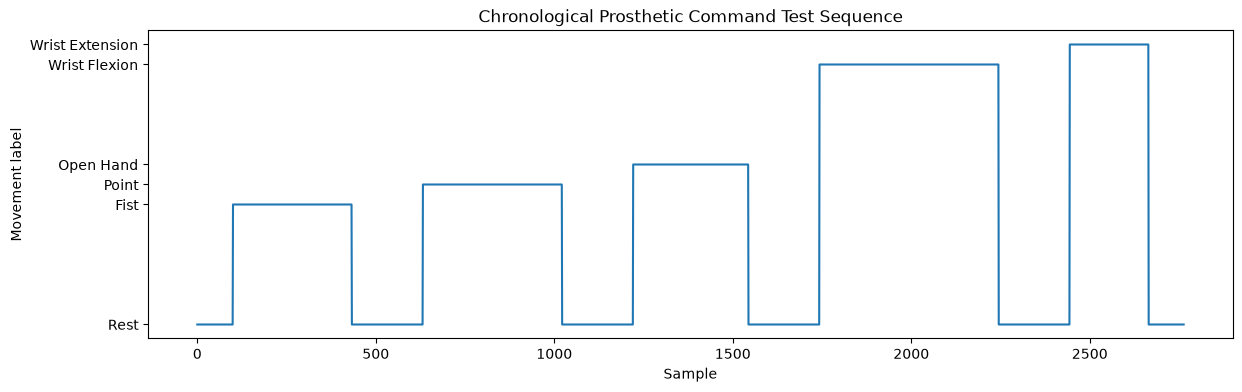

In [6]:
plt.figure(figsize=(14, 4))

plt.plot(test_labels)

plt.xlabel("Sample")
plt.ylabel("Movement label")
plt.title("Chronological Prosthetic Command Test Sequence")

plt.yticks(
    commands,
    [command_map[c] for c in commands]
)

plt.show()

In [7]:
def predict_sequence(model, sequence_emg, history_length=5):
    raw_predictions = []
    smoothed_predictions = []
    true_labels = []

    probability_history = deque(
        maxlen=history_length
    )

    for start in range(
        0,
        len(sequence_emg) - window_size + 1,
        step_size
    ):
        window = sequence_emg[
            start:start + window_size
        ]

        features = extract_features(
            window
        ).reshape(1, -1)

        # Raw Random Forest probabilities
        probabilities = model.predict_proba(
            features
        )[0]

        raw_prediction = model.classes_[
            np.argmax(probabilities)
        ]

        # Save current probabilities for temporal smoothing
        probability_history.append(
            probabilities
        )

        history = np.array(
            probability_history
        )

        # Give newer predictions more weight
        weights = np.arange(
            1,
            len(history) + 1,
            dtype=float
        )

        weights /= weights.sum()

        smoothed_probabilities = np.average(
            history,
            axis=0,
            weights=weights
        )

        smoothed_prediction = model.classes_[
            np.argmax(smoothed_probabilities)
        ]

        # True label at center of window
        center = (
            start + window_size // 2
        )

        true_label = test_labels[
            center
        ]

        raw_predictions.append(
            raw_prediction
        )

        smoothed_predictions.append(
            smoothed_prediction
        )

        true_labels.append(
            true_label
        )

    return (
        np.array(raw_predictions),
        np.array(smoothed_predictions),
        np.array(true_labels)
    )

In [8]:
raw_pred, smooth_pred, true_pred = predict_sequence(
    model,
    test_emg,
    history_length=5
)

print("Number of windows:", len(true_pred))

Number of windows: 275


In [9]:
from sklearn.metrics import accuracy_score

raw_accuracy = accuracy_score(
    true_pred,
    raw_pred
)

smooth_accuracy = accuracy_score(
    true_pred,
    smooth_pred
)

print(
    f"Raw accuracy: {raw_accuracy * 100:.2f}%"
)

print(
    f"Smoothed accuracy: {smooth_accuracy * 100:.2f}%"
)

Raw accuracy: 92.73%
Smoothed accuracy: 95.27%


In [10]:
def count_switches(predictions):
    return np.sum(
        predictions[1:]
        != predictions[:-1]
    )

In [11]:
raw_switches = count_switches(
    raw_pred
)

smooth_switches = count_switches(
    smooth_pred
)

print(
    "Raw command switches:",
    raw_switches
)

print(
    "Smoothed command switches:",
    smooth_switches
)

Raw command switches: 25
Smoothed command switches: 14
